In [ ]:
from piano_string_utils import *

# Problem Statement
From *Discrete Signals and Inverse Problems*: Design a musical instrument to produce a 2 kHz frequency sound (e.g. wind, percussion, string). Understand the underlying physical processes and develop an analytical model to predict the resonant frequency of the instrument. Use the audio capabilities in your computer to digitize the signal and corroborate the frequency content. What is the shape Of the signal? How can you alter the frequency?

This notebook is organized as follows:
1. Instrument choice and analytical model to find instrument design parameters
2. Signal synthesis using Karplus-Strong
3. FFT to corroborate frequency content, harmonic structure
4. Signal shape
5. Altering frequency
6. Discussion
8. References


## I. Inverse Problem: Designing a piano string for a desired pitch

The pitch from the note played by a key of a piano is a stretched (ideal) string under tension, with the fundamental frequency given by $$f = \frac{1}{2L}\sqrt{\frac{T}{\mu}}$$ [1]

where $ T $ is tension, $L$ is length, and $\mu$ is line density/linear mass density. I ignore the effects of things such as inharmonicity and hammer strike position and velocity for simplicity.  

To get a frequency $f_{0}$ of 2 kHz, we need a tension of $$ T = \mu(2Lf_{0})^2$$ 


and $\mu$ is given by $$ (\pi d^2)/4 \rho$$ where $\rho$ is the density of the string and $d$ is the diameter of the string.

I assume a standard steel string which has a density of 7850 kg/m $^{3}$, a diameter $d = 1\times10^{3}m$ and a length $L = .1$m, consistent with the high notes on a piano.

In [2]:
# Define parameters
L = .1 # m, consistent with high notes on piano
d = 1e-3 # m, diameter of string
rho = 7850 # kg/m^3, density of standard steel
mu = ((np.pi * d**2) / 4) * rho # linear mass density of string
print(f'mu: {mu} kg/m')

# Find tension that gives a frequency of 2000 Hz (2 kHz)
f = 2000 # Hz
T = mu * (2*L*f)**2 # N
print(f'tension: {T:.4f} N')


mu: 0.0061653755826699685 kg/m
tension: 986.4601 N


I then verify that the instrument design produces the desired frequency, concluding the analytical portion of this inverse problem.

In [ ]:
# Check
f = string_frequency(L, T, mu)
print(f'Calculated frequency: {f:.2f} Hz')

Calculated frequency: 2000.00 Hz


## II. Signal Synthesis with Karplus-Strong
I choose the Karplus-Strong algorithm [2] which simulates an oscillating wave by using a delay line with feedback.
1. Fill a buffer of length `N = sample_rate/f0` with noise
2. Repeatedly:
    1. output the current sample
    2. compute the new sample as the average of the two **oldest** samples in the buffer and push to the end of the buffer

This updating physically simulates damping, affecting higher frequencies faster than low ones. 

In [3]:
# Generate the signal
f0 = 2000 # Hz
sample_rate = 44100 # Hz, CD quality audio
duration = 2 # seconds, duration of time that the note is played

signal, N = karplus_strong(f0, sample_rate, duration, seed=42)

print(f"Buffer length N = {N} samples, which corresponds to a frequency of {sample_rate/N:.2f} Hz")
print(f"Actual achievable frequency = sample rate / N: {sample_rate / N:.2f} Hz")


Buffer length N = 22 samples, which corresponds to a frequency of 2004.55 Hz
Actual achievable frequency = sample rate / N: 2004.55 Hz


## Verifying with FFT
Plotting the raw signal given by `karplus_strong` does't give visually meaningful results

In [6]:
peak_freqs_raw = check_peaks(signal, sample_rate, title="FFT of Raw Signal (DC offset included)")
print(f"Peak frequencies found (raw): {np.round(peak_freqs_raw[:10], 1)}")

TypeError: check_peaks() got an unexpected keyword argument 'title'

Additionally, automatic peak detection was unsuccessful using the raw signal, because the magnitude of the DC signal was so strong that the fundamental frequency was returned as 0 Hz instead of the real frequency of 2 kHz

In [ ]:





# Check harmonics
for n in range(1, 5):
    expected = n * peak_freq       # self-consistency check: is spacing uniform relative to measured fundamental?
    target = n * f0                 # physics check: does it match the original 2000 Hz design target?
    actual = peak_freqs[n - 1]
    
    error_vs_expected = abs(expected - actual) / expected * 100
    error_vs_target = abs(target - actual) / target * 100
    
    print(f''' {'-'*10} Harmonic {n} {'-'*15} 
 Expected (n * measured f0) ~{expected:.1f} Hz 
 Target   (n * design f0)   ~{target:.1f} Hz 
 Actual (FFT peak):          {actual:.1f} Hz 
 % Error vs measured f0:     {error_vs_expected:.2f}%
 % Error vs design target:   {error_vs_target:.2f}%
''')

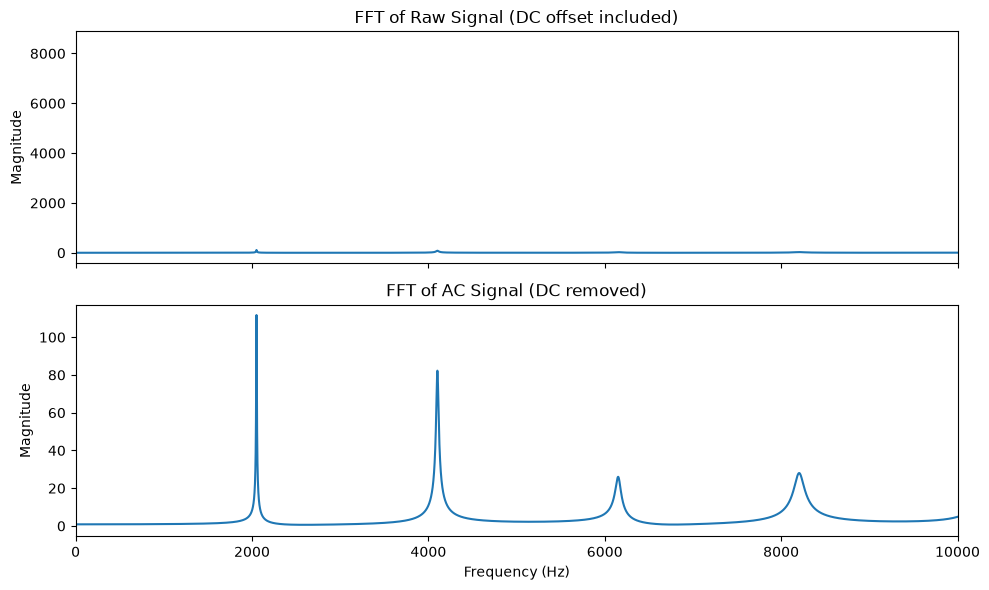

In [71]:
signal_ac = signal - np.mean(signal)  # Remove DC offset

# FFT of AC signal (DC removed)
fft_ac = np.fft.fft(signal_ac)
freqs_ac = np.fft.fftfreq(len(signal_ac), 1/sample_rate)
mag_ac = np.abs(fft_ac)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(freqs_raw[freqs_raw >= 0], mag_raw[freqs_raw >= 0])
axes[0].set_title("FFT of Raw Signal (DC offset included)")
axes[0].set_ylabel("Magnitude")

axes[1].plot(freqs_ac[freqs_ac >= 0], mag_ac[freqs_ac >= 0])
axes[1].set_title("FFT of AC Signal (DC removed)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")

axes[0].set_xlim(0, 10000)
axes[1].set_xlim(0, 10000)

plt.tight_layout()
plt.show()

In [45]:
# Check the peaks
freqs_pos = fft_freqs[fft_freqs >= 0]
mag_pos = magnitude[fft_freqs >= 0]

# Find peaks with a minimum height to avoid noise
peaks, properties = find_peaks(mag_pos, height = np.max(mag_pos)*0.01, distance = 20)
peak_freqs = freqs_pos[peaks]
print(f"Peak frequencies found: {np.round(peak_freqs[:10], 1)}")




# Check harmonics
for n in range(1, 5):
    expected = n * peak_freq       # self-consistency check: is spacing uniform relative to measured fundamental?
    target = n * f0                 # physics check: does it match the original 2000 Hz design target?
    actual = peak_freqs[n - 1]
    
    error_vs_expected = abs(expected - actual) / expected * 100
    error_vs_target = abs(target - actual) / target * 100
    
    print(f''' {'-'*10} Harmonic {n} {'-'*15} 
 Expected (n * measured f0) ~{expected:.1f} Hz 
 Target   (n * design f0)   ~{target:.1f} Hz 
 Actual (FFT peak):          {actual:.1f} Hz 
 % Error vs measured f0:     {error_vs_expected:.2f}%
 % Error vs design target:   {error_vs_target:.2f}%
''')

Peak frequencies found: [ 2051.   4102.5  6152.   8204.5 10250.5 12299.  14341.5 16411.  20604. ]
 ---------- Harmonic 1 --------------- 
 Expected (n * measured f0) ~2051.0 Hz 
 Target   (n * design f0)   ~2000.0 Hz 
 Actual (FFT peak):          2051.0 Hz 
 % Error vs measured f0:     0.00%
 % Error vs design target:   2.55%

 ---------- Harmonic 2 --------------- 
 Expected (n * measured f0) ~4102.0 Hz 
 Target   (n * design f0)   ~4000.0 Hz 
 Actual (FFT peak):          4102.5 Hz 
 % Error vs measured f0:     0.01%
 % Error vs design target:   2.56%

 ---------- Harmonic 3 --------------- 
 Expected (n * measured f0) ~6153.0 Hz 
 Target   (n * design f0)   ~6000.0 Hz 
 Actual (FFT peak):          6152.0 Hz 
 % Error vs measured f0:     0.02%
 % Error vs design target:   2.53%

 ---------- Harmonic 4 --------------- 
 Expected (n * measured f0) ~8204.0 Hz 
 Target   (n * design f0)   ~8000.0 Hz 
 Actual (FFT peak):          8204.5 Hz 
 % Error vs measured f0:     0.01%
 % Error vs de

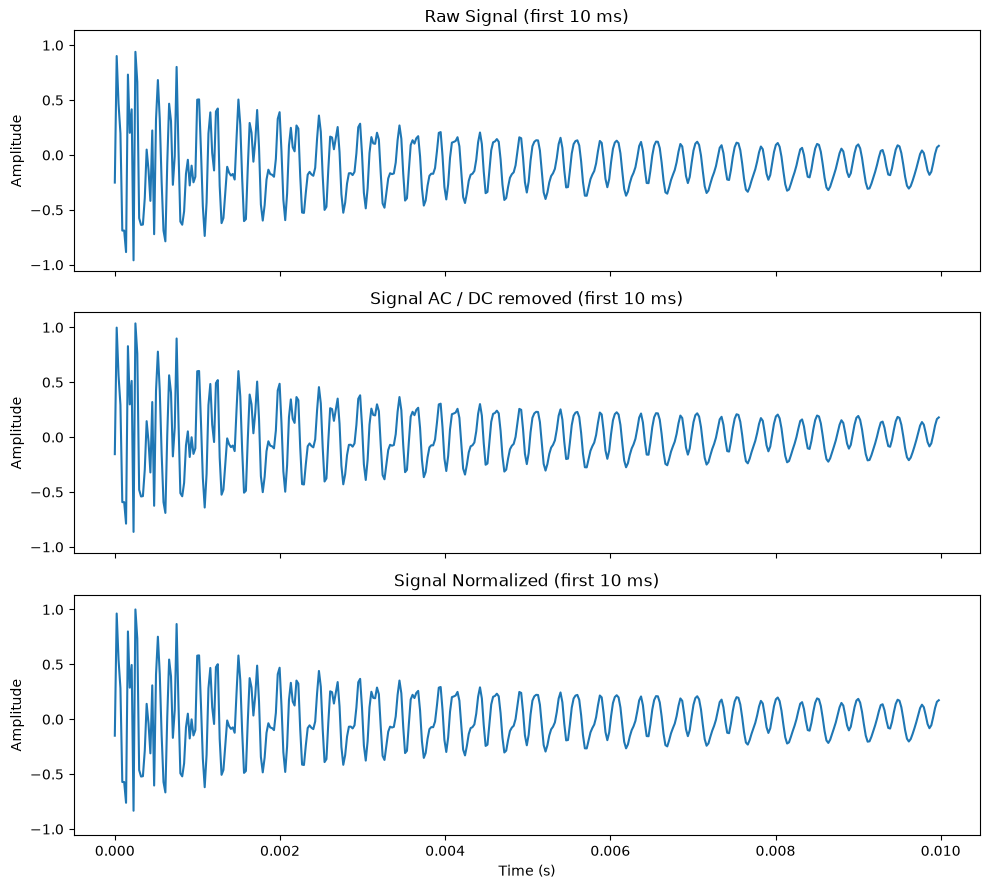

In [59]:
# Step 4: Waveform in time domain
signal_norm = signal_ac / np.max(np.abs(signal_ac))  # normalize to [-1, 1]

# Plot amplitude vs time to show deecaying oscillation
t = np.arange(len(signal)) / sample_rate
n_samples_to_plot = int(0.01 * sample_rate)  # first 10 ms

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True, sharey=True)

axes[0].plot(t[:n_samples_to_plot], signal[:n_samples_to_plot])
axes[0].set_title("Raw Signal (first 10 ms)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(t[:n_samples_to_plot], signal_ac[:n_samples_to_plot])
axes[1].set_title("Signal AC / DC removed (first 10 ms)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(t[:n_samples_to_plot], signal_norm[:n_samples_to_plot])
axes[2].set_title("Signal Normalized (first 10 ms)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

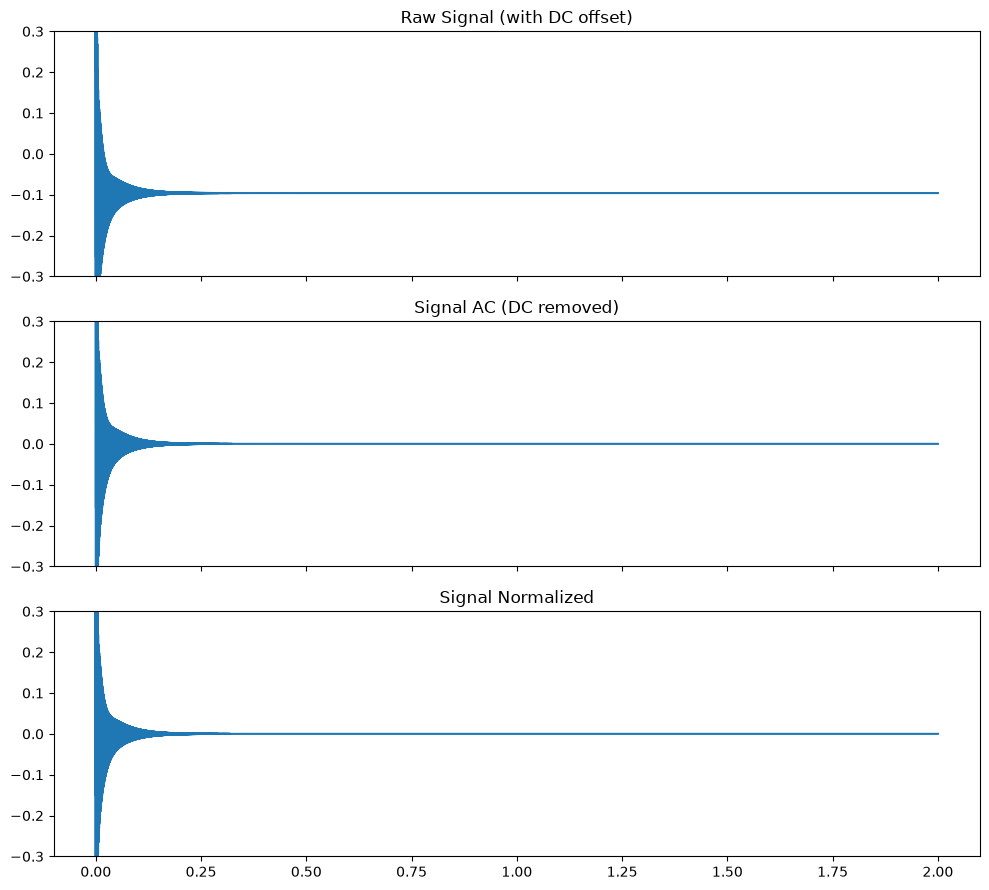

In [57]:
# Step 5: Testing the sound

sd.play(signal_norm, sample_rate)
sd.wait()

t = np.arange(len(signal)) / sample_rate

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(t, signal)
axes[0].set_ylim(-0.3, 0.3)  # zoom in near zero
axes[0].set_title("Raw Signal (with DC offset)")

axes[1].plot(t, signal_ac)
axes[1].set_ylim(-0.3, 0.3)
axes[1].set_title("Signal AC (DC removed)")

axes[2].plot(t, signal_norm)
axes[2].set_ylim(-0.3, 0.3)
axes[2].set_title("Signal Normalized")

plt.tight_layout()
plt.show()

# Interpreting Results

## References
